# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 3</span>

### Exercise 03.1 <span style="color:red"> Plain vanilla option pricing </span>

Black-Scholes theory assumes that the time evolution of the asset price is stochastic and exhibits geometric Brownian motion (GBM) with constant risk-free interest rate $r$ and volatility $\sigma$.

Black-Scholes <span style="color:blue"> analytic solution </span> for the price at time t<T:
- European Call-option price:
$$ C\left[ S(t),t \right] = S(t) N(d_1) -K e^{-r(T-t)} N(d_2) $$
- European Put-option price:
$$ P\left[ S(t),t \right] = S(t) \left[ N(d_1)-1\right] -K e^{-r(T-t)} \left[ N(d_2)-1\right]$$

where 
$$d_1 = \frac{1}{\sigma\sqrt{T-t}}\left[ \ln \left( \frac{S(t)}{K} \right) + \left( r+\frac{\sigma^2}{2} (T-t) \right)\right]$$

where $d_2 = d_1 - \sigma\sqrt{T-t}$, and where
$$ N(x) = \int_{-\infty}^{x} dz \, e^{-\frac{z^2}{2}} = \frac{1}{2} \left[ 1+ {\rm erf} \left( \frac{x}{\sqrt{2}}\right) \right]$$
is the cumulative of Gaussian $\sim \mathcal{N}(\mu=0,\sigma^2=1)$,
and where
$${\rm erf}(x) = \frac{2}{\sqrt{\pi}}\int_{0}^{x} dz \, e^{-z^2}$$

By using the following parameters: 
- asset price at $t=0$: $S(0)=100$
- delivery time: $T=1$
- strike price: $K=100$
- risk-free interest rate: $r=0.1$
- volatility: $\sigma=0.25$

compute at time $t=0$ **via Monte Carlo** the European call-option price, $C[S(0),0]$, and put-option price, $P[S(0),0]$:

1. <span style="color:red">By sampling **directly** the final asset price</span> $\color{red}{S(T)}$ for a $GBM(r, \sigma^2)$
2. <span style="color:red">By sampling the discretized</span> $\color{red}{GBM(r, \sigma^2)}$ <span style="color:red">path of the asset price</span>
dividing $[0,T]$ in $10^2$ time intervals: $S(0)$, $S(t_1)$, $S(t_2)$, ... up to $S(t_{100}=T=1)$


<div style="border:2px solid #F5F5F5; padding: 1em; background-color:#F5F5F5; border-radius: 5px; color: #333333;">

Remember that given an asset price $S\sim GBM(\mu,\sigma^2)$, with initial value $S(0)$, then:
$$S(t) = S(0) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$
where $W(t)\sim\mathcal{N}(0,t)$.

Moreover, since the increments of $W$ are independent and normally distributed, the simple recursive procedure for sampling discretized values of $S\sim GBM(\mu,\sigma^2)$ at $t_1 < t_2 < \dots < t_n$ is:
$$S(t_{i+1}) = S(t_i) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i) + \sigma Z_{i+1}\sqrt{t_{i+1}-t_i}\right]$$
with $Z_i \sim \mathcal{N}(0,1)$.

</div>


<span style="color:red">Make four pictures for the estimation of the European call-option prices,</span> $\color{red}{C[S(0),0]}$ <span style="color:red">(direct and discretized), and put-option prices,</span> $\color{red}{P[S(0),0]}$ <span style="color:red">(direct and discretized), with their uncertainties</span> with a large number of asset prices at time $t=T$, say $M\ge 10^4$, as a function of the number of blocks, $N$. <span style="color:blue">As usual, in computing statistical uncertainties, use data blocking.</span>

### For comparison, Black-Scholes analytic solution:

In [1]:
import scipy
from scipy.special import erf
import numpy
from numpy import exp
from numpy.lib.scimath import log, sqrt

# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


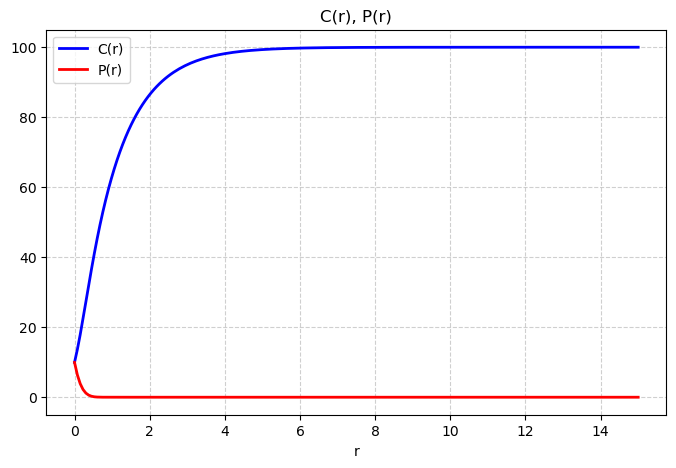

In [8]:
import matplotlib.pyplot as plt
import numpy as np
# Genera i dati
# np.linspace crea 400 punti tra 0 e 20
r_variable = np.linspace(0, 15, 200) 
c, p = black_scholes(S0, K, T, r_variable, sigma)

# Crea il plot
plt.figure(figsize=(8, 5))
plt.plot(r_variable, c, label="C(r)", color='blue', linewidth=2)
plt.plot(r_variable, p, label="P(r)", color='red', linewidth=2)

# Aggiungi dettagli (titoli, griglia, legenda)
plt.title("C(r), P(r)")
plt.xlabel("r")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Mostra il grafico
plt.show()

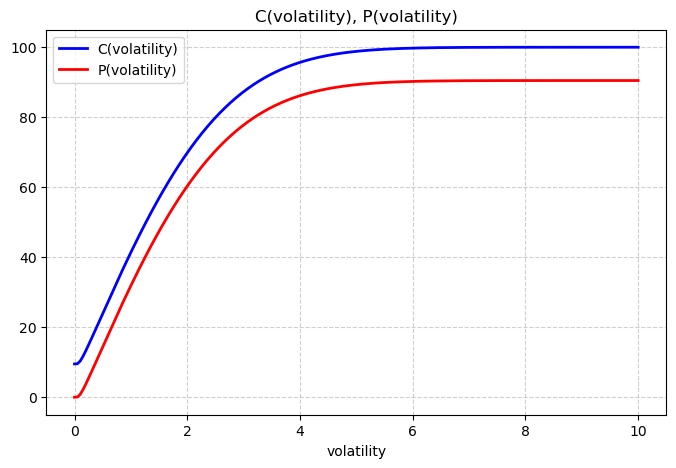

In [7]:
# Genera i dati
sigma_variable = np.linspace(0.000001, 10, 200) 
c, p = black_scholes(S0, K, T, r, sigma_variable)

# Crea il plot
plt.figure(figsize=(8, 5))
plt.plot(sigma_variable, c, label="C(volatility)", color='blue', linewidth=2)
plt.plot(sigma_variable, p, label="P(volatility)", color='red', linewidth=2)

# Aggiungi dettagli (titoli, griglia, legenda)
plt.title("C(volatility), P(volatility)")
plt.xlabel("volatility")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Mostra il grafico
plt.show()

/tmp/ipykernel_45074/1473234481.py:19: RuntimeWarning: divide by zero encountered in divide
  d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
/tmp/ipykernel_45074/1473234481.py:19: RuntimeWarning: invalid value encountered in multiply
  d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)


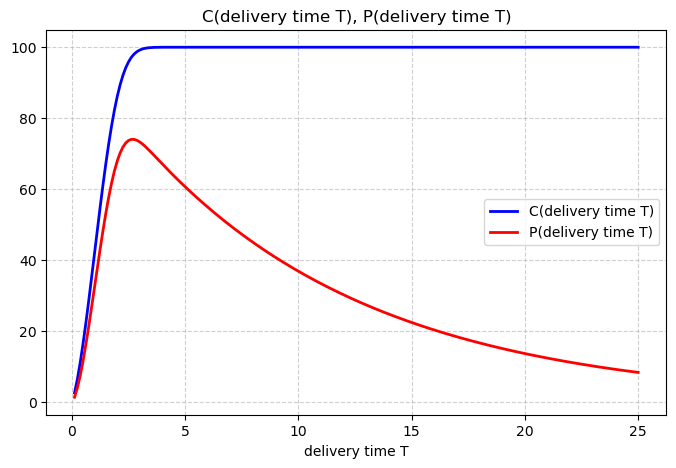

In [10]:
# Genera i dati
T_variable = np.linspace(0, 25, 200) 
c, p = black_scholes(S0, K, T_variable, r, T_variable)

# Crea il plot
plt.figure(figsize=(8, 5))
plt.plot(T_variable, c, label="C(delivery time T)", color='blue', linewidth=2)
plt.plot(T_variable, p, label="P(delivery time T)", color='red', linewidth=2)

# Aggiungi dettagli (titoli, griglia, legenda)
plt.title("C(delivery time T), P(delivery time T)")
plt.xlabel("delivery time T")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Mostra il grafico
plt.show()